In [1]:
import pandas as pd
df = pd.read_csv("StudentsPerformance.csv")
df.columns = df.columns.str.strip()


In [2]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [4]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [5]:
df.shape

(1000, 8)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [7]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
le = LabelEncoder()
df["lunch"] = le.fit_transform(df["lunch"])
df["race/ethnicity"] = le.fit_transform(df["race/ethnicity"])
df["parental level of education"] = le.fit_transform(df["parental level of education"])
df["test preparation course"] = le.fit_transform(df["test preparation course"])
df["gender"] = le.fit_transform(df["gender"])

In [10]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75


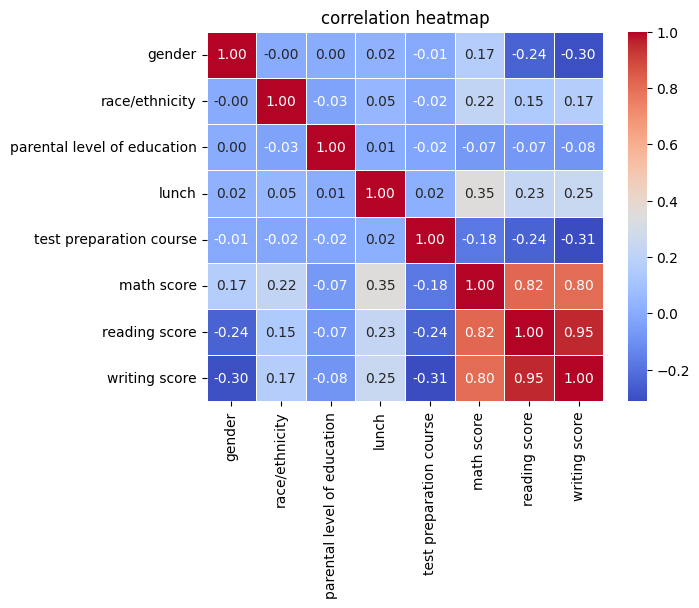

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidth=0.5)
plt.title("correlation heatmap")
plt.show()

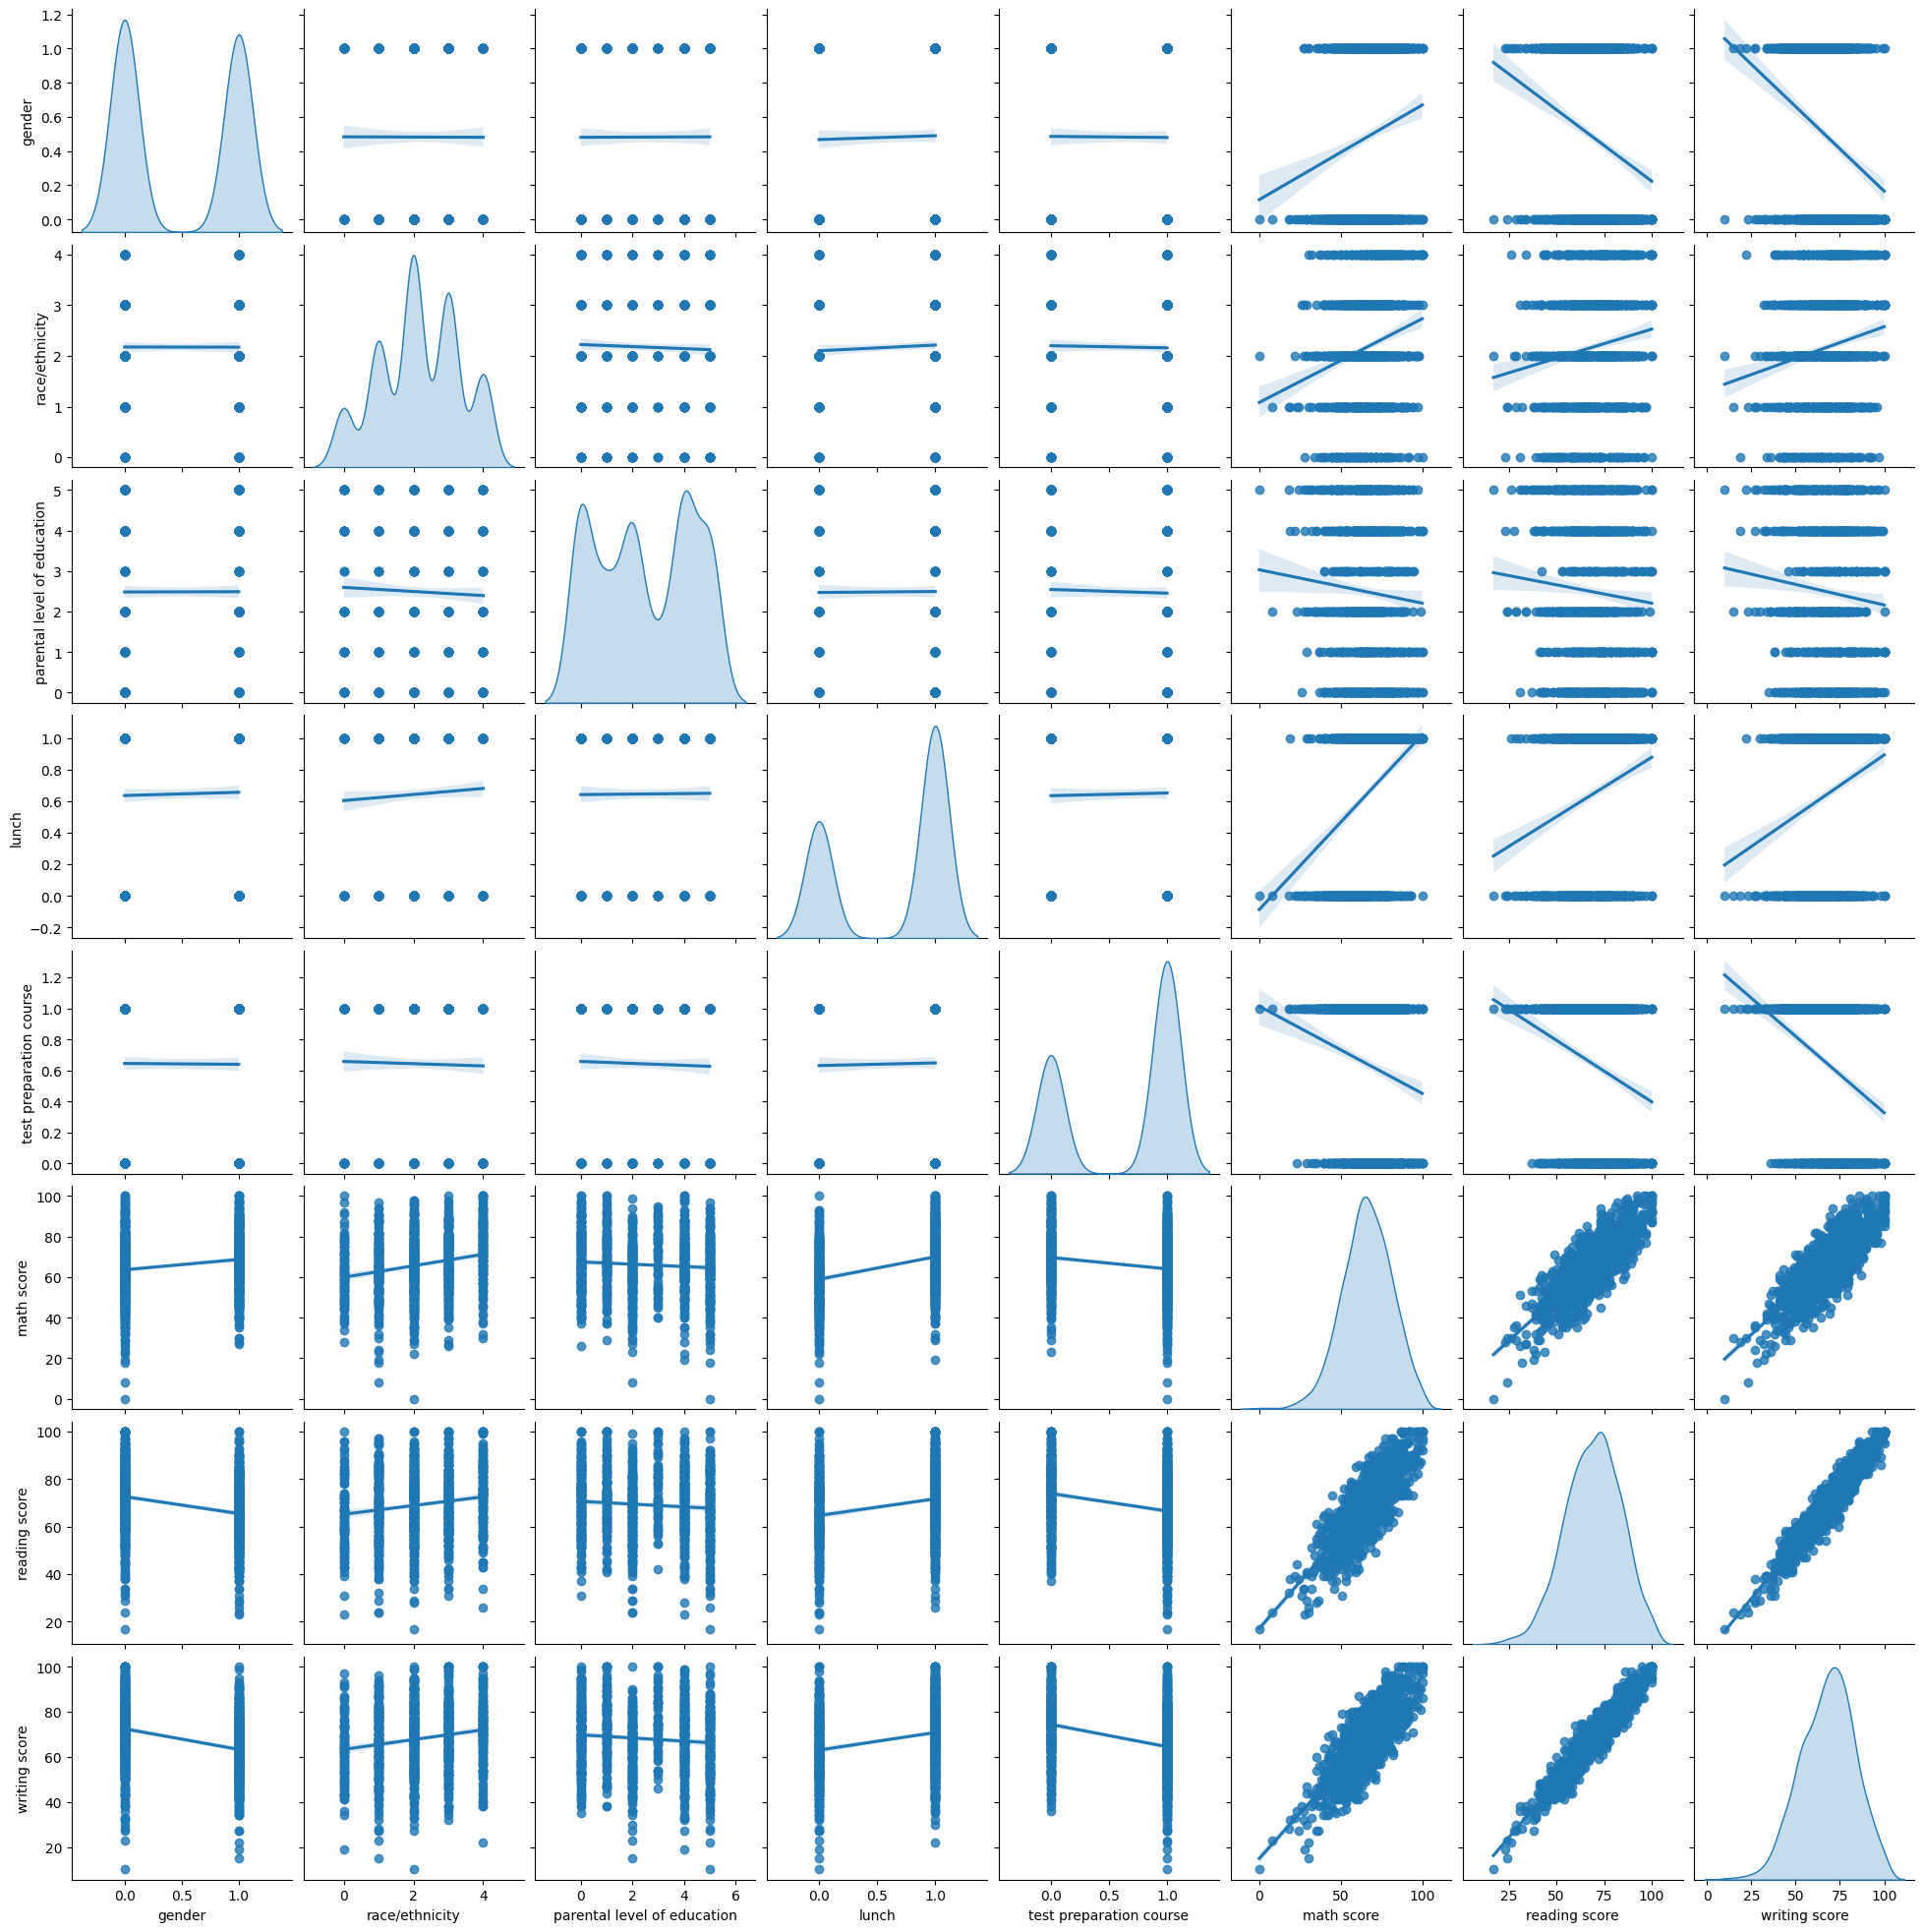

In [12]:
sns.pairplot(data=df, kind="reg", diag_kind="kde")
plt.show()

In [13]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75


In [14]:
y = df["math score"]
#X = df[["gender","race/ethnicity","lunch","reading score","writing score"]]
X = df.drop(columns=["math score"])
scaler = StandardScaler()


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[6.46,0.98,0.28,...,1.31,4.66,9.44]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,66.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,7
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[43.29,28.86,28.58,...,27.45,22.28, 5.5 ]"


In [16]:
y_pred = model.predict(X_test_scaled)

In [17]:
model.score(X_test_scaled, y_test)

0.8838026201112221

In [18]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"{r2} is the r2_ score")
print(f"{mae} is the mean absolute error")
print(f"{mse} is the mean squared error")

0.8838026201112221 is the r2_ score
4.130145078004058 is the mean absolute error
28.27528450632738 is the mean squared error


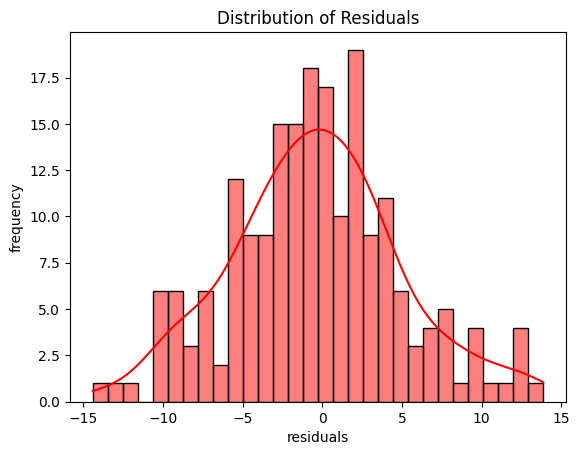

In [19]:
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color="red", bins=30)
plt.xlabel("residuals")
plt.ylabel("frequency")
plt.title("Distribution of Residuals")
plt.show()

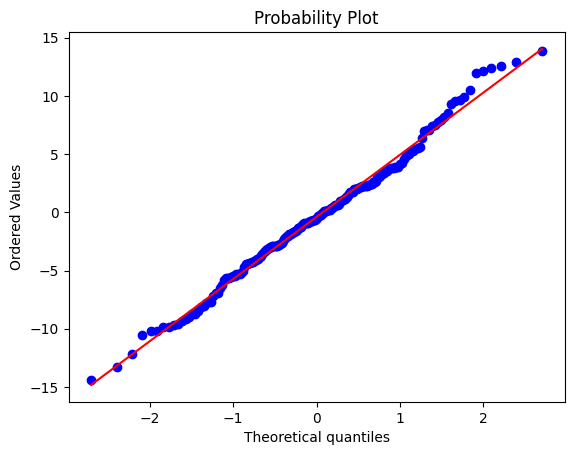

In [20]:
import pylab
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [22]:
from xgboost import XGBRegressor
modex = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4,eval_metric="rmse")
modex.fit(X_train_scaled, y_train)
yx_pred = modex.predict(X_test_scaled)
r2_x = r2_score(y_test, yx_pred)
mae_x = mean_absolute_error(y_test, yx_pred)
mse_x = mean_squared_error(y_test, yx_pred)

In [23]:
print(f"{r2_x} is the r2_ score")
print(f"{mae_x} is the mean absolute error")
print(f"{mse_x} is the mean squared error")

0.8727380037307739 is the r2_ score
4.294133186340332 is the mean absolute error
30.967729568481445 is the mean squared error
